# Astana PM2.5 Forecasting and High-Pollution Event Modeling


## Imports and environment setup


In [1]:
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, confusion_matrix
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

XGB_AVAILABLE = True
LGBM_AVAILABLE = True
CATBOOST_AVAILABLE = True

try:
    from xgboost import XGBRegressor, XGBClassifier
except Exception:
    XGB_AVAILABLE = False

try:
    from lightgbm import LGBMRegressor, LGBMClassifier
except Exception:
    LGBM_AVAILABLE = False

try:
    from catboost import CatBoostRegressor, CatBoostClassifier
except Exception:
    CATBOOST_AVAILABLE = False


## Configuration


In [2]:
DATA_PATH = Path("astana_dataset.csv")
ARTIFACT_DIR = Path("artifacts_astana_pm25_article")
FIG_DIR = ARTIFACT_DIR / "figures"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATE_COL = "date"
TARGET_COL = "pm25"
FORECAST_HORIZON_DAYS = 1
HOLDOUT_DAYS = 365
SEED = 42
N_ITER_SEARCH = 12
CV_VAL_SIZE = 180
CV_GAP = 1
CV_MIN_TRAIN = 730
ROW_NON_NULL_THRESHOLD = 0.60

np.random.seed(SEED)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 260)


## Dependency availability


In [3]:
pd.DataFrame({
    "package": ["xgboost", "lightgbm", "catboost"],
    "available": [XGB_AVAILABLE, LGBM_AVAILABLE, CATBOOST_AVAILABLE]
})


,package,available
0,xgboost,True
1,lightgbm,True
2,catboost,True


## Load and validate dataset


In [4]:
df_raw = pd.read_csv(DATA_PATH)
df_raw.columns = [c.strip() for c in df_raw.columns]
df_raw[DATE_COL] = pd.to_datetime(df_raw[DATE_COL], errors="coerce")
df_raw = df_raw.dropna(subset=[DATE_COL]).sort_values(DATE_COL).drop_duplicates(subset=[DATE_COL], keep="last").reset_index(drop=True)

for c in df_raw.columns:
    if c != DATE_COL:
        df_raw[c] = pd.to_numeric(df_raw[c], errors="coerce")

df_raw.shape, df_raw.head()


((2798, 93),
         date   pm25  pm10  no2  no  so2  co  h2s  tsp  temp_mean  temp_max  temp_min  humidity_mean  humidity_max  humidity_min  dew_point_mean  dew_point_max  dew_point_min  pressure_mean  pressure_max  pressure_min  wind_speed_mean  wind_speed_max  \
 0 2018-07-27  25.33   NaN  NaN NaN  NaN NaN  NaN  NaN       21.5      26.3      15.9             59            82            38            12.6           15.6           10.9          977.1         978.2         976.0             13.1            18.3   
 1 2018-07-28  17.48   NaN  NaN NaN  NaN NaN  NaN  NaN       19.3      25.5      13.1             56            85            30             9.6           11.5            6.7          976.0         976.9         975.1             11.8            20.1   
 2 2018-07-29  18.64   NaN  NaN NaN  NaN NaN  NaN  NaN       21.1      27.5      14.9             53            83            26            10.0           12.4            6.4          974.9         976.2         973.9        

## Data audit


In [5]:
audit = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": [str(df_raw[c].dtype) for c in df_raw.columns],
    "missing_rate": [df_raw[c].isna().mean() for c in df_raw.columns],
    "n_unique": [df_raw[c].nunique(dropna=True) for c in df_raw.columns]
}).sort_values(["missing_rate", "column"], ascending=[False, True]).reset_index(drop=True)

date_min = df_raw[DATE_COL].min()
date_max = df_raw[DATE_COL].max()

print("date_min =", date_min)
print("date_max =", date_max)
print("n_rows =", len(df_raw))
print("pm25_non_null =", int(df_raw[TARGET_COL].notna().sum()))
print("pm25_missing_rate =", float(df_raw[TARGET_COL].isna().mean()))
audit.head(25)


date_min = 2018-07-27 00:00:00
date_max = 2026-03-24 00:00:00
n_rows = 2798
pm25_non_null = 2201
pm25_missing_rate = 0.21336669049320944


,column,dtype,missing_rate,n_unique
0,tsp,float64,0.555039,1189
1,pm10,float64,0.502859,1242
2,no,float64,0.494639,1276
3,no2,float64,0.494639,1299
4,co,float64,0.493924,1391
5,h2s,float64,0.493924,665
6,so2,float64,0.493924,1127
7,pm25,float64,0.213367,1836
8,pblh_change_1d,float64,0.065404,2322
9,ventilation_change_1d,float64,0.065404,2614


## Reindex to full daily calendar


In [6]:
df = (
    df_raw
    .set_index(DATE_COL)
    .sort_index()
    .asfreq("D")
    .reset_index()
    .rename(columns={"index": DATE_COL})
)

df.shape, df.head()


((2798, 93),
         date   pm25  pm10  no2  no  so2  co  h2s  tsp  temp_mean  temp_max  temp_min  humidity_mean  humidity_max  humidity_min  dew_point_mean  dew_point_max  dew_point_min  pressure_mean  pressure_max  pressure_min  wind_speed_mean  wind_speed_max  \
 0 2018-07-27  25.33   NaN  NaN NaN  NaN NaN  NaN  NaN       21.5      26.3      15.9             59            82            38            12.6           15.6           10.9          977.1         978.2         976.0             13.1            18.3   
 1 2018-07-28  17.48   NaN  NaN NaN  NaN NaN  NaN  NaN       19.3      25.5      13.1             56            85            30             9.6           11.5            6.7          976.0         976.9         975.1             11.8            20.1   
 2 2018-07-29  18.64   NaN  NaN NaN  NaN NaN  NaN  NaN       21.1      27.5      14.9             53            83            26            10.0           12.4            6.4          974.9         976.2         973.9        

## Core figures for the article


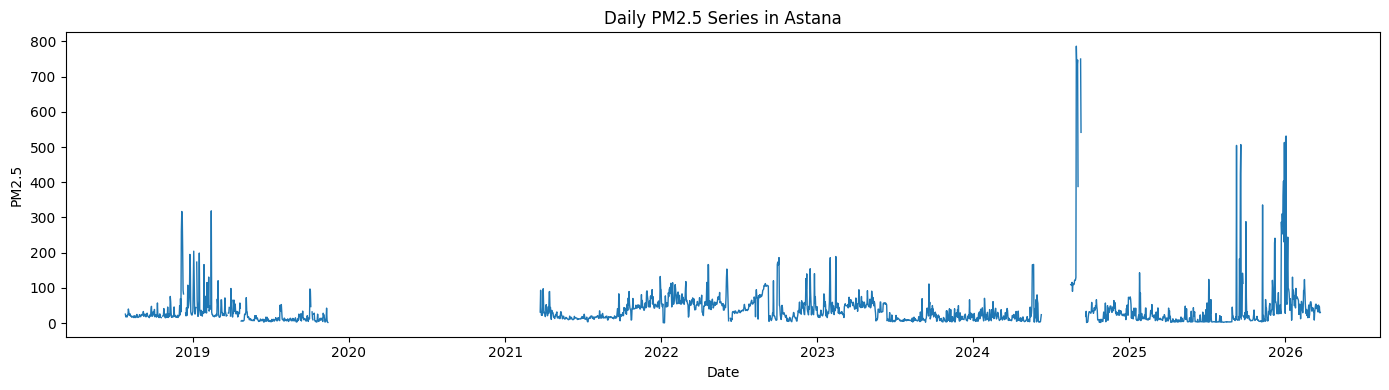

PosixPath('artifacts_astana_pm25_article/figures/figure_01_pm25_series.png')

In [7]:
fig_path = FIG_DIR / "figure_01_pm25_series.png"
plt.figure(figsize=(14, 4))
plt.plot(df[DATE_COL], df[TARGET_COL], linewidth=1)
plt.title("Daily PM2.5 Series in Astana")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.tight_layout()
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

fig_path


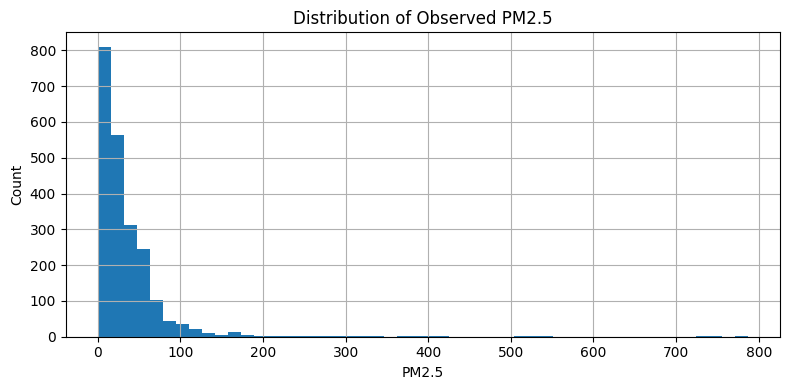

PosixPath('artifacts_astana_pm25_article/figures/figure_02_pm25_distribution.png')

In [8]:
fig_path = FIG_DIR / "figure_02_pm25_distribution.png"
plt.figure(figsize=(8, 4))
df[TARGET_COL].dropna().hist(bins=50)
plt.title("Distribution of Observed PM2.5")
plt.xlabel("PM2.5")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

fig_path


## Feature engineering


In [9]:
def build_supervised(data: pd.DataFrame, horizon: int = 1) -> pd.DataFrame:
    x = data.copy().sort_values(DATE_COL).reset_index(drop=True)

    x["target"] = x[TARGET_COL].shift(-horizon)

    x["dayofweek"] = x[DATE_COL].dt.dayofweek
    x["month"] = x[DATE_COL].dt.month
    x["dayofyear"] = x[DATE_COL].dt.dayofyear
    x["is_weekend"] = (x["dayofweek"] >= 5).astype(int)
    x["is_cold_season"] = x["month"].isin([10, 11, 12, 1, 2, 3]).astype(int)

    x["dow_sin"] = np.sin(2 * np.pi * x["dayofweek"] / 7)
    x["dow_cos"] = np.cos(2 * np.pi * x["dayofweek"] / 7)
    x["month_sin"] = np.sin(2 * np.pi * x["month"] / 12)
    x["month_cos"] = np.cos(2 * np.pi * x["month"] / 12)
    x["doy_sin"] = np.sin(2 * np.pi * x["dayofyear"] / 365.25)
    x["doy_cos"] = np.cos(2 * np.pi * x["dayofyear"] / 365.25)

    for lag in [1, 2, 3, 7, 14]:
        x[f"pm25_lag_{lag}"] = x[TARGET_COL].shift(lag)

    y_shift = x[TARGET_COL].shift(1)
    for w in [3, 7, 14, 30]:
        x[f"pm25_roll_mean_{w}"] = y_shift.rolling(w, min_periods=1).mean()
        x[f"pm25_roll_std_{w}"] = y_shift.rolling(w, min_periods=2).std()
        x[f"pm25_roll_min_{w}"] = y_shift.rolling(w, min_periods=1).min()
        x[f"pm25_roll_max_{w}"] = y_shift.rolling(w, min_periods=1).max()

    x["pm25_diff_1d"] = x[TARGET_COL].diff(1)
    x["pm25_diff_3d"] = x[TARGET_COL].diff(3)
    x["pm25_pct_change_1d"] = x[TARGET_COL].pct_change(1).replace([np.inf, -np.inf], np.nan)

    global_q90 = x[TARGET_COL].quantile(0.90)
    high_flag = (x[TARGET_COL] >= global_q90).astype(float)
    x["pm25_high_count_7d"] = high_flag.shift(1).rolling(7, min_periods=1).sum()
    x["pm25_high_count_14d"] = high_flag.shift(1).rolling(14, min_periods=1).sum()

    idx = np.arange(len(x), dtype=float)
    last_valid_idx = pd.Series(np.where(x[TARGET_COL].notna(), idx, np.nan)).ffill()
    x["days_since_last_pm25"] = idx - last_valid_idx
    x["pm25_missing_flag"] = x[TARGET_COL].isna().astype(int)

    x["season_group"] = np.where(x["is_cold_season"] == 1, "cold", "warm")

    sparse_pollutants = ["pm10", "tsp", "no2", "so2"]
    for col in sparse_pollutants:
        if col in x.columns:
            x[f"{col}_curr"] = pd.to_numeric(x[col], errors="coerce")
            x[f"{col}_missing_flag"] = x[f"{col}_curr"].isna().astype(int)

    x = x.replace([np.inf, -np.inf], np.nan)
    return x

df_feat = build_supervised(df, horizon=FORECAST_HORIZON_DAYS)
df_feat.shape, df_feat.head()


((2798, 142),
         date   pm25  pm10  no2  no  so2  co  h2s  tsp  temp_mean  temp_max  temp_min  humidity_mean  humidity_max  humidity_min  dew_point_mean  dew_point_max  dew_point_min  pressure_mean  pressure_max  pressure_min  wind_speed_mean  wind_speed_max  \
 0 2018-07-27  25.33   NaN  NaN NaN  NaN NaN  NaN  NaN       21.5      26.3      15.9             59            82            38            12.6           15.6           10.9          977.1         978.2         976.0             13.1            18.3   
 1 2018-07-28  17.48   NaN  NaN NaN  NaN NaN  NaN  NaN       19.3      25.5      13.1             56            85            30             9.6           11.5            6.7          976.0         976.9         975.1             11.8            20.1   
 2 2018-07-29  18.64   NaN  NaN NaN  NaN NaN  NaN  NaN       21.1      27.5      14.9             53            83            26            10.0           12.4            6.4          974.9         976.2         973.9       

## Feature policy


In [10]:
core_features = [
    "pm25_lag_1", "pm25_lag_2", "pm25_lag_3", "pm25_lag_7", "pm25_lag_14",
    "pm25_roll_mean_3", "pm25_roll_mean_7", "pm25_roll_mean_14", "pm25_roll_mean_30",
    "pm25_roll_std_3", "pm25_roll_std_7", "pm25_roll_std_14", "pm25_roll_std_30",
    "pm25_roll_min_7", "pm25_roll_max_7",
    "pm25_diff_1d", "pm25_diff_3d", "pm25_pct_change_1d",
    "pm25_high_count_7d", "pm25_high_count_14d",
    "days_since_last_pm25", "pm25_missing_flag",
    "is_weekend", "is_cold_season",
    "dow_sin", "dow_cos", "month_sin", "month_cos", "doy_sin", "doy_cos",
    "temp_mean", "temp_max", "temp_min", "temp_range",
    "humidity_mean", "humidity_range",
    "dew_point_mean", "dew_point_depression",
    "wind_speed_mean", "wind_speed_max", "wind_gust_max", "wind_gust_excess",
    "u10_mean", "v10_mean",
    "pressure_mean", "pressure_range",
    "pressure_change_1d", "pressure_change_2d", "pressure_change_3d",
    "precip_sum", "precip_hours", "days_since_last_precip",
    "snowfall_sum", "snow_flag",
    "cloud_mean", "radiation_sum",
    "vpd_max", "vpd_mean",
    "pblh_mean", "pblh_min", "pblh_max",
    "ventilation_proxy", "pblh_change_1d", "ventilation_change_1d",
    "heating_degree_days", "calm_wind_hours", "calm_day_flag", "calm_wind_streak"
]

core_features = [c for c in core_features if c in df_feat.columns]

feature_sets = {
    "CORE": core_features,
    "CORE_PM10": core_features + [c for c in ["pm10_curr", "pm10_missing_flag"] if c in df_feat.columns],
    "CORE_TSP": core_features + [c for c in ["tsp_curr", "tsp_missing_flag"] if c in df_feat.columns],
    "CORE_PM10_TSP": core_features + [c for c in ["pm10_curr", "pm10_missing_flag", "tsp_curr", "tsp_missing_flag"] if c in df_feat.columns]
}

pd.DataFrame({
    "feature_set": list(feature_sets.keys()),
    "n_features": [len(v) for v in feature_sets.values()]
})


,feature_set,n_features
0,CORE,68
1,CORE_PM10,70
2,CORE_TSP,70
3,CORE_PM10_TSP,72


## Date-based split


In [11]:
holdout_start_date = df_feat[DATE_COL].max() - pd.Timedelta(days=HOLDOUT_DAYS - 1)

train_mask = df_feat[DATE_COL] < holdout_start_date
holdout_mask = df_feat[DATE_COL] >= holdout_start_date

train_df_all = df_feat.loc[train_mask].copy()
holdout_df_all = df_feat.loc[holdout_mask].copy()

print("train_start =", train_df_all[DATE_COL].min())
print("train_end =", train_df_all[DATE_COL].max())
print("holdout_start =", holdout_df_all[DATE_COL].min())
print("holdout_end =", holdout_df_all[DATE_COL].max())


train_start = 2018-07-27 00:00:00
train_end = 2025-03-24 00:00:00
holdout_start = 2025-03-25 00:00:00
holdout_end = 2026-03-24 00:00:00


## Metrics and fold creation


In [12]:
def smape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float, copy=True)
    y_pred = np.array(y_pred, dtype=float, copy=True)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    out = np.zeros_like(y_true, dtype=float)
    out[mask] = 2 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask]
    return 100 * out.mean()

def evaluate_regression(y_true, y_pred):
    y_true = np.array(y_true, dtype=float, copy=True)
    y_pred = np.array(y_pred, dtype=float, copy=True)
    mask = (~np.isnan(y_true)) & (~np.isnan(y_pred))
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) == 0:
        return {"mae": np.nan, "rmse": np.nan, "r2": np.nan, "smape": np.nan}
    y_pred = np.clip(y_pred, 0, None)
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
        "smape": float(smape(y_true, y_pred))
    }

def evaluate_classification(y_true, y_score, threshold=0.5):
    y_true = np.array(y_true, dtype=int, copy=True)
    y_score = np.array(y_score, dtype=float, copy=True)
    mask = (~np.isnan(y_true)) & (~np.isnan(y_score))
    y_true = y_true[mask]
    y_score = y_score[mask]
    y_pred = (y_score >= threshold).astype(int)
    pr_auc = float(average_precision_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else np.nan
    precision = float(precision_score(y_true, y_pred, zero_division=0))
    recall = float(recall_score(y_true, y_pred, zero_division=0))
    f1 = float(f1_score(y_true, y_pred, zero_division=0))
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "pr_auc": pr_auc,
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "tn": int(tn)
    }

def make_time_series_folds(n_rows, n_splits=5, val_size=180, gap=1, min_train_size=730):
    folds = []
    end_train = min_train_size
    while True:
        train_end = end_train
        val_start = train_end + gap
        val_end = val_start + val_size
        if val_end > n_rows:
            break
        folds.append((np.arange(0, train_end), np.arange(val_start, val_end)))
        end_train += val_size
    if len(folds) > n_splits:
        folds = folds[-n_splits:]
    return folds


## Prepare matrices


In [13]:
def prepare_xy(df_part, features):
    tmp = df_part.dropna(subset=["target"]).reset_index(drop=True).copy()
    X = tmp[features].copy()
    y_reg = tmp["target"].copy()
    row_keep = X.notna().mean(axis=1) >= ROW_NON_NULL_THRESHOLD
    tmp = tmp.loc[row_keep].reset_index(drop=True)
    X = X.loc[row_keep].reset_index(drop=True)
    y_reg = y_reg.loc[row_keep].reset_index(drop=True)
    high_thr = float(tmp["target"].quantile(0.90))
    y_cls = (tmp["target"] >= high_thr).astype(int)
    return tmp, X, y_reg, y_cls, high_thr

prepared = {}
for feature_set_name, features in feature_sets.items():
    train_df, X_train, y_train_reg, y_train_cls, train_thr = prepare_xy(train_df_all, features)
    holdout_df, X_holdout, y_holdout_reg, _, _ = prepare_xy(holdout_df_all, features)
    y_holdout_cls = (holdout_df["target"] >= train_thr).astype(int)
    folds = make_time_series_folds(
        n_rows=len(train_df),
        n_splits=5,
        val_size=CV_VAL_SIZE,
        gap=CV_GAP,
        min_train_size=CV_MIN_TRAIN
    )
    prepared[feature_set_name] = {
        "features": features,
        "train_df": train_df,
        "holdout_df": holdout_df,
        "X_train": X_train,
        "y_train_reg": y_train_reg,
        "y_train_cls": y_train_cls,
        "X_holdout": X_holdout,
        "y_holdout_reg": y_holdout_reg,
        "y_holdout_cls": y_holdout_cls,
        "high_thr": train_thr,
        "folds": folds
    }

pd.DataFrame({
    "feature_set": list(prepared.keys()),
    "train_rows": [len(prepared[k]["train_df"]) for k in prepared],
    "holdout_rows": [len(prepared[k]["holdout_df"]) for k in prepared],
    "n_features": [len(prepared[k]["features"]) for k in prepared]
})


,feature_set,train_rows,holdout_rows,n_features
0,CORE,1839,361,68
1,CORE_PM10,1839,361,70
2,CORE_TSP,1839,361,70
3,CORE_PM10_TSP,1839,361,72


## Baseline regression


In [14]:
baseline_rows = []

for feature_set_name, bundle in prepared.items():
    train_df = bundle["train_df"]
    holdout_df = bundle["holdout_df"]
    folds = bundle["folds"]

    for fold_id, (_, val_idx) in enumerate(folds, start=1):
        val_df = train_df.iloc[val_idx].copy()
        pred_val = val_df["pm25_roll_mean_7"].values
        reg = evaluate_regression(val_df["target"], pred_val)
        baseline_rows.append({
            "feature_set": feature_set_name,
            "model": "Rolling7_Baseline",
            "scope": "cv",
            "fold": fold_id,
            **reg
        })

    pred_holdout = holdout_df["pm25_roll_mean_7"].values
    reg = evaluate_regression(holdout_df["target"], pred_holdout)
    baseline_rows.append({
        "feature_set": feature_set_name,
        "model": "Rolling7_Baseline",
        "scope": "holdout",
        "fold": np.nan,
        **reg
    })

baseline_regression = pd.DataFrame(baseline_rows)
baseline_regression.head()


,feature_set,model,scope,fold,mae,rmse,r2,smape
0,CORE,Rolling7_Baseline,cv,1.0,21.350278,37.529943,-0.001331,46.741986
1,CORE,Rolling7_Baseline,cv,2.0,18.294921,28.345539,-0.294386,38.656065
2,CORE,Rolling7_Baseline,cv,3.0,8.526351,13.565381,0.036772,51.397204
3,CORE,Rolling7_Baseline,cv,4.0,15.862568,28.157938,-0.162023,62.888839
4,CORE,Rolling7_Baseline,cv,5.0,32.236439,101.178212,0.385286,53.767451


## Regression model definitions


In [15]:
reg_models = {}
reg_param_spaces = {}

rf_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=SEED, n_jobs=-1))
])
reg_models["RandomForest"] = rf_reg
reg_param_spaces["RandomForest"] = {
    "model__n_estimators": [300, 500, 800, 1200],
    "model__max_depth": [4, 6, 8, 10, 12, None],
    "model__min_samples_leaf": [1, 2, 4, 8, 12],
    "model__max_features": ["sqrt", 0.5, 0.7, 1.0]
}

if XGB_AVAILABLE:
    xgb_reg = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBRegressor(
            objective="reg:squarederror",
            random_state=SEED,
            n_estimators=800,
            n_jobs=-1
        ))
    ])
    reg_models["XGBoost"] = xgb_reg
    reg_param_spaces["XGBoost"] = {
        "model__n_estimators": [300, 500, 800, 1200],
        "model__max_depth": [3, 4, 5, 6, 8],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.08],
        "model__subsample": [0.6, 0.8, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
        "model__min_child_weight": [1, 3, 5, 8]
    }

if LGBM_AVAILABLE:
    lgbm_reg = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", LGBMRegressor(
            random_state=SEED,
            n_estimators=800,
            verbose=-1
        ))
    ])
    reg_models["LightGBM"] = lgbm_reg
    reg_param_spaces["LightGBM"] = {
        "model__n_estimators": [300, 500, 800, 1200],
        "model__num_leaves": [15, 31, 63, 127],
        "model__max_depth": [-1, 4, 6, 8, 10],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.08],
        "model__subsample": [0.6, 0.8, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
        "model__min_child_samples": [10, 20, 40, 80]
    }

if CATBOOST_AVAILABLE:
    cat_reg = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", CatBoostRegressor(
            random_seed=SEED,
            verbose=False,
            loss_function="RMSE"
        ))
    ])
    reg_models["CatBoost"] = cat_reg
    reg_param_spaces["CatBoost"] = {
        "model__iterations": [300, 500, 800, 1200],
        "model__depth": [4, 5, 6, 8],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.08],
        "model__l2_leaf_reg": [1, 3, 5, 7, 9],
        "model__subsample": [0.6, 0.8, 1.0]
    }

list(reg_models.keys())


['RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']

## Regression randomized search


In [16]:
reg_search_rows = []
best_reg_estimators = {}

for feature_set_name, bundle in prepared.items():
    X_train = bundle["X_train"]
    y_train = bundle["y_train_reg"]
    folds = bundle["folds"]

    for model_name in reg_models:
        search = RandomizedSearchCV(
            estimator=clone(reg_models[model_name]),
            param_distributions=reg_param_spaces[model_name],
            n_iter=N_ITER_SEARCH,
            scoring="neg_mean_absolute_error",
            n_jobs=-1,
            cv=folds,
            random_state=SEED,
            refit=True,
            verbose=0
        )
        search.fit(X_train, y_train)
        reg_search_rows.append({
            "task": "regression",
            "feature_set": feature_set_name,
            "model": model_name,
            "best_cv_mae": -float(search.best_score_),
            "best_params": search.best_params_
        })
        best_reg_estimators[(feature_set_name, model_name)] = search.best_estimator_

reg_search_results = pd.DataFrame(reg_search_rows).sort_values(["best_cv_mae", "feature_set", "model"]).reset_index(drop=True)
reg_search_results


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

,task,feature_set,model,best_cv_mae,best_params
0,regression,CORE_PM10,RandomForest,18.841535,"{'model__n_estimators': 1200, 'model__min_samp..."
1,regression,CORE_PM10_TSP,RandomForest,18.903227,"{'model__n_estimators': 1200, 'model__min_samp..."
2,regression,CORE,RandomForest,18.937215,"{'model__n_estimators': 1200, 'model__min_samp..."
3,regression,CORE_TSP,RandomForest,19.583812,"{'model__n_estimators': 1200, 'model__min_samp..."
4,regression,CORE_PM10,XGBoost,19.675157,"{'model__subsample': 0.6, 'model__n_estimators..."
5,regression,CORE_PM10,CatBoost,19.840827,"{'model__subsample': 1.0, 'model__learning_rat..."
6,regression,CORE_PM10,LightGBM,19.864619,"{'model__subsample': 0.8, 'model__num_leaves':..."
7,regression,CORE_PM10_TSP,XGBoost,19.865218,"{'model__subsample': 1.0, 'model__n_estimators..."
8,regression,CORE,XGBoost,19.886492,"{'model__subsample': 0.6, 'model__n_estimators..."
9,regression,CORE_PM10_TSP,CatBoost,20.000981,"{'model__subsample': 1.0, 'model__learning_rat..."


## Regression CV and holdout summary


In [17]:
cv_reg_rows = []

for feature_set_name, bundle in prepared.items():
    X_train = bundle["X_train"]
    y_train = bundle["y_train_reg"]
    folds = bundle["folds"]

    for model_name in reg_models:
        est = best_reg_estimators[(feature_set_name, model_name)]
        for fold_id, (tr_idx, val_idx) in enumerate(folds, start=1):
            fitted = clone(est)
            fitted.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
            pred = fitted.predict(X_train.iloc[val_idx])
            reg = evaluate_regression(y_train.iloc[val_idx], pred)
            cv_reg_rows.append({
                "feature_set": feature_set_name,
                "model": model_name,
                "fold": fold_id,
                **reg
            })

cv_reg_results = pd.DataFrame(cv_reg_rows)

cv_reg_summary = (
    cv_reg_results
    .groupby(["feature_set", "model"], as_index=False)
    .agg(
        mae_mean=("mae", "mean"),
        mae_std=("mae", "std"),
        rmse_mean=("rmse", "mean"),
        r2_mean=("r2", "mean"),
        smape_mean=("smape", "mean")
    )
)

baseline_cv_reg_summary = (
    baseline_regression.loc[baseline_regression["scope"] == "cv"]
    .groupby(["feature_set", "model"], as_index=False)
    .agg(
        mae_mean=("mae", "mean"),
        mae_std=("mae", "std"),
        rmse_mean=("rmse", "mean"),
        r2_mean=("r2", "mean"),
        smape_mean=("smape", "mean")
    )
)

cv_reg_comparison = pd.concat([baseline_cv_reg_summary, cv_reg_summary], ignore_index=True).sort_values(["mae_mean", "rmse_mean"]).reset_index(drop=True)
cv_reg_comparison


,feature_set,model,mae_mean,mae_std,rmse_mean,r2_mean,smape_mean
0,CORE_PM10,RandomForest,18.841535,10.348483,41.839409,0.184942,47.710498
1,CORE_PM10_TSP,RandomForest,18.903227,10.369484,41.836698,0.184498,47.966073
2,CORE,RandomForest,18.937215,10.638567,41.819410,0.183817,47.976581
3,CORE,Rolling7_Baseline,19.254111,8.666634,41.755403,-0.007136,50.690309
4,CORE_PM10,Rolling7_Baseline,19.254111,8.666634,41.755403,-0.007136,50.690309
5,CORE_PM10_TSP,Rolling7_Baseline,19.254111,8.666634,41.755403,-0.007136,50.690309
6,CORE_TSP,Rolling7_Baseline,19.254111,8.666634,41.755403,-0.007136,50.690309
7,CORE_TSP,RandomForest,19.583812,11.080707,41.995390,0.171339,49.275445
8,CORE_PM10,XGBoost,19.675157,10.094637,42.095417,0.134769,50.122942
9,CORE_PM10,CatBoost,19.840827,10.344806,42.926300,0.134378,51.192842


In [18]:
holdout_reg_rows = []
final_reg_models = {}

for feature_set_name, bundle in prepared.items():
    X_train = bundle["X_train"]
    y_train = bundle["y_train_reg"]
    X_holdout = bundle["X_holdout"]
    y_holdout = bundle["y_holdout_reg"]
    holdout_df = bundle["holdout_df"]

    baseline_pred = holdout_df["pm25_roll_mean_7"].values
    reg = evaluate_regression(y_holdout, baseline_pred)
    holdout_reg_rows.append({
        "feature_set": feature_set_name,
        "model": "Rolling7_Baseline",
        **reg
    })

    for model_name in reg_models:
        fitted = clone(best_reg_estimators[(feature_set_name, model_name)])
        fitted.fit(X_train, y_train)
        pred = fitted.predict(X_holdout)
        reg = evaluate_regression(y_holdout, pred)
        holdout_reg_rows.append({
            "feature_set": feature_set_name,
            "model": model_name,
            **reg
        })
        final_reg_models[(feature_set_name, model_name)] = fitted

holdout_reg_summary = pd.DataFrame(holdout_reg_rows).sort_values(["mae", "rmse"]).reset_index(drop=True)
holdout_reg_summary


,feature_set,model,mae,rmse,r2,smape
0,CORE_PM10_TSP,RandomForest,28.340409,69.758009,0.287449,71.260615
1,CORE_PM10,RandomForest,28.465897,69.524735,0.292207,71.237496
2,CORE_TSP,RandomForest,28.738778,69.408481,0.294572,72.179544
3,CORE,RandomForest,29.067313,69.103008,0.300768,72.443653
4,CORE_TSP,CatBoost,29.424845,74.552131,0.186144,73.658923
5,CORE_PM10,CatBoost,29.648816,72.869751,0.222461,76.763773
6,CORE_PM10_TSP,CatBoost,29.871900,72.856191,0.222750,77.176216
7,CORE,CatBoost,29.914675,72.035141,0.240170,77.550484
8,CORE_TSP,LightGBM,30.943123,71.592682,0.249476,73.849873
9,CORE,LightGBM,30.962771,71.554889,0.250268,76.544300


## Regression champion selection


In [19]:
holdout_reg_for_merge = holdout_reg_summary.rename(columns={
    "mae": "mae_holdout",
    "rmse": "rmse_holdout",
    "r2": "r2_holdout",
    "smape": "smape_holdout"
})

merged_reg = cv_reg_comparison.merge(
    holdout_reg_for_merge,
    on=["feature_set", "model"],
    how="inner"
)

best_cv_mae = merged_reg["mae_mean"].min()
eligible_reg = merged_reg.loc[merged_reg["mae_mean"] <= best_cv_mae * 1.05].copy()
if len(eligible_reg) == 0:
    eligible_reg = merged_reg.copy()

eligible_reg = eligible_reg.sort_values(
    ["mae_holdout", "rmse_holdout", "mae_mean"],
    ascending=[True, True, True]
).reset_index(drop=True)

regression_champion = eligible_reg.iloc[0].to_dict()
regression_champion


{'feature_set': 'CORE_PM10_TSP',
 'model': 'RandomForest',
 'mae_mean': 18.903226579308182,
 'mae_std': 10.36948396657437,
 'rmse_mean': 41.836697864312164,
 'r2_mean': 0.18449838480751712,
 'smape_mean': 47.966072593516245,
 'mae_holdout': 28.34040925354167,
 'rmse_holdout': 69.75800908487899,
 'r2_holdout': 0.28744933137276685,
 'smape_holdout': 71.26061468293726}

## Regression champion diagnostics and article figures


In [20]:
reg_feature_set = regression_champion["feature_set"]
reg_model_name = regression_champion["model"]
reg_bundle = prepared[reg_feature_set]

if reg_model_name == "Rolling7_Baseline":
    reg_model = None
    reg_holdout_pred = reg_bundle["holdout_df"]["pm25_roll_mean_7"].values
else:
    reg_model = final_reg_models[(reg_feature_set, reg_model_name)]
    reg_holdout_pred = reg_model.predict(reg_bundle["X_holdout"])

pred_df = reg_bundle["holdout_df"][[DATE_COL, TARGET_COL, "target", "season_group"]].copy()
pred_df["prediction"] = np.clip(np.array(reg_holdout_pred, dtype=float, copy=True), 0, None)
pred_df["abs_error"] = np.abs(pred_df["target"] - pred_df["prediction"])
final_regression_metrics = evaluate_regression(pred_df["target"], pred_df["prediction"])
final_regression_metrics


{'mae': 28.34040925354167,
 'rmse': 69.75800908487899,
 'r2': 0.28744933137276685,
 'smape': 71.26061468293726}

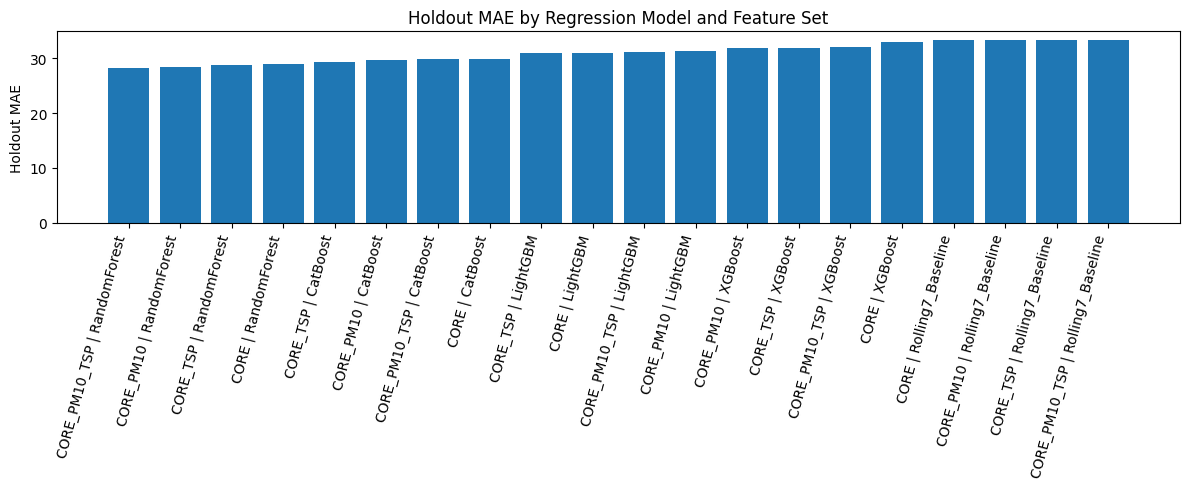

PosixPath('artifacts_astana_pm25_article/figures/figure_03_model_comparison_holdout_mae.png')

In [21]:
fig_path = FIG_DIR / "figure_03_model_comparison_holdout_mae.png"
plot_df = holdout_reg_summary.copy()
labels = plot_df["feature_set"] + " | " + plot_df["model"]
plt.figure(figsize=(12, 5))
plt.bar(labels, plot_df["mae"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("Holdout MAE")
plt.title("Holdout MAE by Regression Model and Feature Set")
plt.tight_layout()
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

fig_path


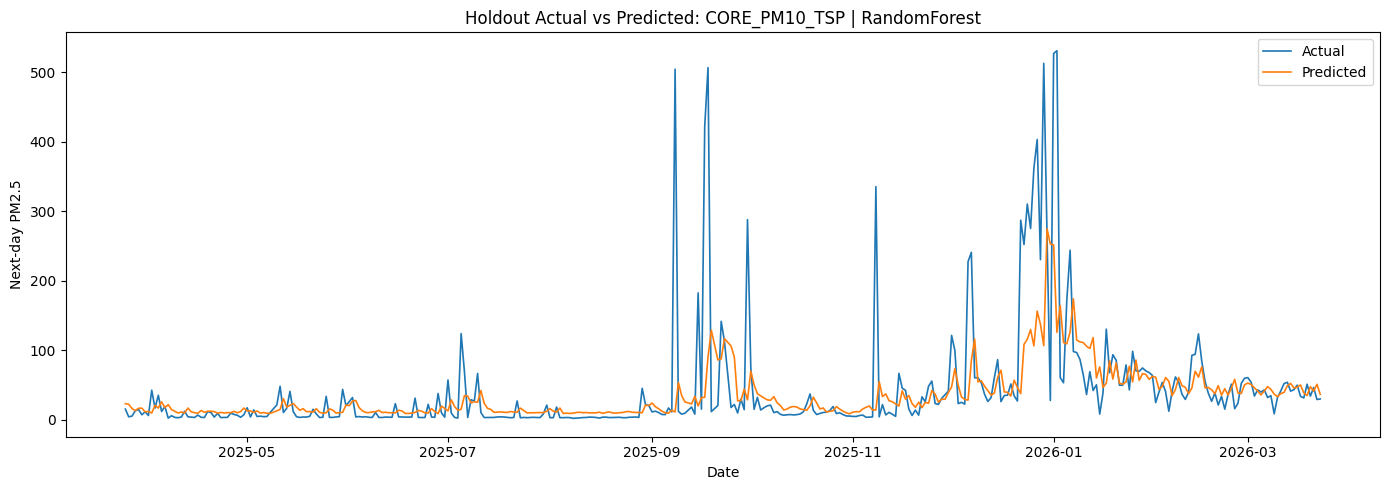

PosixPath('artifacts_astana_pm25_article/figures/figure_04_actual_vs_predicted_holdout.png')

In [22]:
fig_path = FIG_DIR / "figure_04_actual_vs_predicted_holdout.png"
plt.figure(figsize=(14, 5))
plt.plot(pred_df[DATE_COL], pred_df["target"], label="Actual", linewidth=1.2)
plt.plot(pred_df[DATE_COL], pred_df["prediction"], label="Predicted", linewidth=1.2)
plt.title(f"Holdout Actual vs Predicted: {reg_feature_set} | {reg_model_name}")
plt.xlabel("Date")
plt.ylabel("Next-day PM2.5")
plt.legend()
plt.tight_layout()
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

fig_path


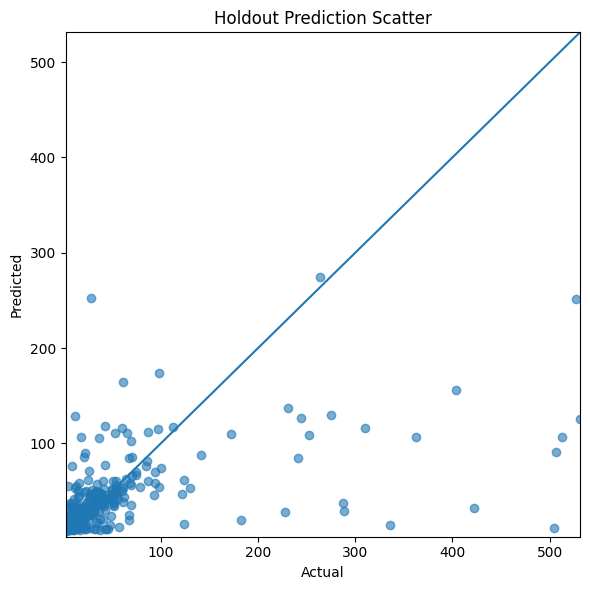

PosixPath('artifacts_astana_pm25_article/figures/figure_05_prediction_scatter.png')

In [23]:
fig_path = FIG_DIR / "figure_05_prediction_scatter.png"
plt.figure(figsize=(6, 6))
plt.scatter(pred_df["target"], pred_df["prediction"], alpha=0.6)
lims = [
    min(pred_df["target"].min(), pred_df["prediction"].min()),
    max(pred_df["target"].max(), pred_df["prediction"].max())
]
plt.plot(lims, lims)
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Holdout Prediction Scatter")
plt.tight_layout()
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

fig_path


In [24]:
seasonal_reg_metrics = (
    pred_df
    .groupby("season_group", as_index=False)
    .apply(lambda g: pd.Series(evaluate_regression(g["target"], g["prediction"])))
    .reset_index(drop=True)
)

monthly_reg_metrics = (
    pred_df.assign(month=pred_df[DATE_COL].dt.to_period("M").astype(str))
    .groupby("month", as_index=False)
    .apply(lambda g: pd.Series(evaluate_regression(g["target"], g["prediction"])))
    .reset_index(drop=True)
)

seasonal_reg_metrics, monthly_reg_metrics.tail(12)


(  season_group        mae       rmse        r2      smape
 0         cold  34.690599  75.029789  0.328064  52.409821
 1         warm  21.954940  64.020699  0.085157  90.216135,
       month        mae        rmse        r2       smape
 1   2025-04   7.828713   10.201733 -0.257801   74.914753
 2   2025-05   9.950901   12.814005 -0.048648   77.065571
 3   2025-06   9.790497   11.321228 -0.226026   94.064825
 4   2025-07  16.953255   26.308599  0.048958  102.929729
 5   2025-08   7.991843    9.730002 -0.233979   99.587464
 6   2025-09  86.723592  161.165682 -0.123295   92.683380
 7   2025-10  10.111235   12.391734  0.109044   58.333053
 8   2025-11  24.602564   61.464097 -0.077904   75.948554
 9   2025-12  87.920101  135.837546 -0.008341   62.499467
 10  2026-01  56.332253   99.918236  0.293434   46.416360
 11  2026-02  17.771864   23.688546  0.150959   38.942815
 12  2026-03   9.110676   11.467424 -0.078655   24.287225)

## Seasonal regression models


In [25]:
seasonal_reg_rows = []

for season_name in ["cold", "warm"]:
    for feature_set_name, bundle in prepared.items():
        season_train = bundle["train_df"].loc[bundle["train_df"]["season_group"] == season_name].reset_index(drop=True)
        season_holdout = bundle["holdout_df"].loc[bundle["holdout_df"]["season_group"] == season_name].reset_index(drop=True)
        if len(season_train) < CV_MIN_TRAIN or len(season_holdout) == 0:
            continue

        X_train = season_train[bundle["features"]].copy()
        y_train = season_train["target"].copy()
        X_holdout = season_holdout[bundle["features"]].copy()
        y_holdout = season_holdout["target"].copy()

        row_keep_train = X_train.notna().mean(axis=1) >= ROW_NON_NULL_THRESHOLD
        row_keep_holdout = X_holdout.notna().mean(axis=1) >= ROW_NON_NULL_THRESHOLD
        X_train = X_train.loc[row_keep_train].reset_index(drop=True)
        y_train = y_train.loc[row_keep_train].reset_index(drop=True)
        X_holdout = X_holdout.loc[row_keep_holdout].reset_index(drop=True)
        y_holdout = y_holdout.loc[row_keep_holdout].reset_index(drop=True)

        if len(X_train) < CV_MIN_TRAIN or len(X_holdout) == 0:
            continue

        folds = make_time_series_folds(
            n_rows=len(X_train),
            n_splits=3,
            val_size=min(120, max(30, len(X_train) // 6)),
            gap=CV_GAP,
            min_train_size=min(CV_MIN_TRAIN, max(180, len(X_train) // 2))
        )
        if len(folds) == 0:
            continue

        if reg_model_name == "Rolling7_Baseline":
            pred = season_holdout.loc[row_keep_holdout, "pm25_roll_mean_7"].values
        else:
            model = clone(reg_models[reg_model_name])
            search = RandomizedSearchCV(
                estimator=model,
                param_distributions=reg_param_spaces[reg_model_name],
                n_iter=min(8, N_ITER_SEARCH),
                scoring="neg_mean_absolute_error",
                n_jobs=-1,
                cv=folds,
                random_state=SEED,
                refit=True,
                verbose=0
            )
            search.fit(X_train, y_train)
            pred = search.best_estimator_.predict(X_holdout)

        metrics = evaluate_regression(y_holdout, pred)
        seasonal_reg_rows.append({
            "season_group": season_name,
            "feature_set": feature_set_name,
            "model": reg_model_name,
            **metrics
        })

seasonal_model_summary = pd.DataFrame(seasonal_reg_rows).sort_values(["season_group", "mae"]).reset_index(drop=True)
seasonal_model_summary


,season_group,feature_set,model,mae,rmse,r2,smape
0,cold,CORE_PM10,RandomForest,36.169071,85.910893,0.119039,53.130230
1,cold,CORE_PM10_TSP,RandomForest,36.243764,85.941849,0.118404,53.306444
2,cold,CORE,RandomForest,36.710463,85.369894,0.130099,55.033541
3,cold,CORE_TSP,RandomForest,36.754109,86.158777,0.113948,55.458649
4,warm,CORE_PM10_TSP,RandomForest,27.023142,70.910587,-0.122349,96.709622
5,warm,CORE_TSP,RandomForest,27.272628,69.644880,-0.082640,97.932138
6,warm,CORE_PM10,RandomForest,27.390135,70.326667,-0.103941,97.508985
7,warm,CORE,RandomForest,28.683323,71.546194,-0.142559,98.164300


## Event classification target


In [26]:
classification_feature_set = "CORE"
cls_bundle = prepared[classification_feature_set]

pd.DataFrame({
    "split": ["train", "holdout"],
    "rows": [len(cls_bundle["train_df"]), len(cls_bundle["holdout_df"])],
    "positive_rate": [float(cls_bundle["y_train_cls"].mean()), float(cls_bundle["y_holdout_cls"].mean())],
    "threshold_pm25": [cls_bundle["high_thr"], cls_bundle["high_thr"]]
})


,split,rows,positive_rate,threshold_pm25
0,train,1839,0.100054,69.63
1,holdout,361,0.121884,69.63


## Classification model definitions


In [27]:
cls_models = {}
cls_param_spaces = {}

rf_cls = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(random_state=SEED, n_jobs=-1))
])
cls_models["RandomForestClassifier"] = rf_cls
cls_param_spaces["RandomForestClassifier"] = {
    "model__n_estimators": [300, 500, 800, 1200],
    "model__max_depth": [4, 6, 8, 10, 12, None],
    "model__min_samples_leaf": [1, 2, 4, 8, 12],
    "model__max_features": ["sqrt", 0.5, 0.7, 1.0],
    "model__class_weight": [None, "balanced"]
}

if XGB_AVAILABLE:
    xgb_cls = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=SEED,
            n_estimators=800,
            n_jobs=-1
        ))
    ])
    cls_models["XGBClassifier"] = xgb_cls
    cls_param_spaces["XGBClassifier"] = {
        "model__n_estimators": [300, 500, 800, 1200],
        "model__max_depth": [3, 4, 5, 6, 8],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.08],
        "model__subsample": [0.6, 0.8, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
        "model__min_child_weight": [1, 3, 5, 8]
    }

if LGBM_AVAILABLE:
    lgbm_cls = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", LGBMClassifier(
            random_state=SEED,
            n_estimators=800,
            verbose=-1
        ))
    ])
    cls_models["LGBMClassifier"] = lgbm_cls
    cls_param_spaces["LGBMClassifier"] = {
        "model__n_estimators": [300, 500, 800, 1200],
        "model__num_leaves": [15, 31, 63, 127],
        "model__max_depth": [-1, 4, 6, 8, 10],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.08],
        "model__subsample": [0.6, 0.8, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
        "model__min_child_samples": [10, 20, 40, 80]
    }

if CATBOOST_AVAILABLE:
    cat_cls = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", CatBoostClassifier(
            random_seed=SEED,
            verbose=False
        ))
    ])
    cls_models["CatBoostClassifier"] = cat_cls
    cls_param_spaces["CatBoostClassifier"] = {
        "model__iterations": [300, 500, 800, 1200],
        "model__depth": [4, 5, 6, 8],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.08],
        "model__l2_leaf_reg": [1, 3, 5, 7, 9],
        "model__subsample": [0.6, 0.8, 1.0]
    }

list(cls_models.keys())


['RandomForestClassifier',
 'XGBClassifier',
 'LGBMClassifier',
 'CatBoostClassifier']

## Classification randomized search and threshold tuning


In [28]:
cls_search_rows = []
best_cls_estimators = {}
best_cls_thresholds = {}

X_train_cls = cls_bundle["X_train"]
y_train_cls = cls_bundle["y_train_cls"]
folds_cls = cls_bundle["folds"]

for model_name in cls_models:
    search = RandomizedSearchCV(
        estimator=clone(cls_models[model_name]),
        param_distributions=cls_param_spaces[model_name],
        n_iter=N_ITER_SEARCH,
        scoring="average_precision",
        n_jobs=-1,
        cv=folds_cls,
        random_state=SEED,
        refit=True,
        verbose=0
    )
    search.fit(X_train_cls, y_train_cls)
    best_cls_estimators[model_name] = search.best_estimator_

    cv_scores = np.full(len(y_train_cls), np.nan, dtype=float)
    for tr_idx, val_idx in folds_cls:
        fitted = clone(search.best_estimator_)
        fitted.fit(X_train_cls.iloc[tr_idx], y_train_cls.iloc[tr_idx])
        if hasattr(fitted, "predict_proba"):
            score = fitted.predict_proba(X_train_cls.iloc[val_idx])[:, 1]
        else:
            score = fitted.decision_function(X_train_cls.iloc[val_idx])
        cv_scores[val_idx] = score

    threshold_grid = np.arange(0.20, 0.81, 0.05)
    threshold_rows = []
    for thr in threshold_grid:
        m = evaluate_classification(y_train_cls, cv_scores, threshold=thr)
        threshold_rows.append({"threshold": float(thr), **m})
    threshold_df = pd.DataFrame(threshold_rows).sort_values(["f1", "pr_auc", "recall"], ascending=[False, False, False]).reset_index(drop=True)
    best_threshold = float(threshold_df.iloc[0]["threshold"])
    best_cls_thresholds[model_name] = best_threshold

    cls_search_rows.append({
        "task": "classification",
        "feature_set": classification_feature_set,
        "model": model_name,
        "best_cv_pr_auc": float(search.best_score_),
        "best_threshold": best_threshold,
        "best_params": search.best_params_
    })

cls_search_results = pd.DataFrame(cls_search_rows).sort_values(["best_cv_pr_auc"], ascending=[False]).reset_index(drop=True)
cls_search_results


,task,feature_set,model,best_cv_pr_auc,best_threshold,best_params
0,classification,CORE,RandomForestClassifier,0.403132,0.3,"{'model__n_estimators': 800, 'model__min_sampl..."
1,classification,CORE,CatBoostClassifier,0.380531,0.2,"{'model__subsample': 1.0, 'model__learning_rat..."
2,classification,CORE,LGBMClassifier,0.342006,0.2,"{'model__subsample': 0.8, 'model__num_leaves':..."
3,classification,CORE,XGBClassifier,0.332385,0.2,"{'model__subsample': 0.6, 'model__n_estimators..."


## Classification holdout summary


In [29]:
classification_rows = []
final_cls_models = {}

for model_name, estimator in best_cls_estimators.items():
    fitted = clone(estimator)
    fitted.fit(cls_bundle["X_train"], cls_bundle["y_train_cls"])
    if hasattr(fitted, "predict_proba"):
        holdout_score = fitted.predict_proba(cls_bundle["X_holdout"])[:, 1]
    else:
        holdout_score = fitted.decision_function(cls_bundle["X_holdout"])
    threshold = best_cls_thresholds[model_name]
    metrics = evaluate_classification(cls_bundle["y_holdout_cls"], holdout_score, threshold=threshold)
    classification_rows.append({
        "feature_set": classification_feature_set,
        "model": model_name,
        "threshold": threshold,
        **metrics
    })
    final_cls_models[model_name] = fitted

classification_summary = pd.DataFrame(classification_rows).sort_values(["f1", "pr_auc", "recall"], ascending=[False, False, False]).reset_index(drop=True)
classification_summary


,feature_set,model,threshold,precision,recall,f1,pr_auc,tp,fp,fn,tn
0,CORE,XGBClassifier,0.2,0.508475,0.681818,0.582524,0.538500,30,29,14,288
1,CORE,LGBMClassifier,0.2,0.621622,0.522727,0.567901,0.510237,23,14,21,303
2,CORE,RandomForestClassifier,0.3,0.475410,0.659091,0.552381,0.560441,29,32,15,285
3,CORE,CatBoostClassifier,0.2,0.555556,0.454545,0.500000,0.518421,20,16,24,301


## Classification champion and article figures


In [30]:
classification_champion = classification_summary.iloc[0].to_dict()
cls_model_name = classification_champion["model"]
cls_model = final_cls_models[cls_model_name]
cls_threshold = float(classification_champion["threshold"])

if hasattr(cls_model, "predict_proba"):
    cls_holdout_score = cls_model.predict_proba(cls_bundle["X_holdout"])[:, 1]
else:
    cls_holdout_score = cls_model.decision_function(cls_bundle["X_holdout"])

cls_eval = evaluate_classification(cls_bundle["y_holdout_cls"], cls_holdout_score, threshold=cls_threshold)
cls_eval


{'precision': 0.5084745762711864,
 'recall': 0.6818181818181818,
 'f1': 0.5825242718446602,
 'pr_auc': 0.5384998126494291,
 'tp': 30,
 'fp': 29,
 'fn': 14,
 'tn': 288}

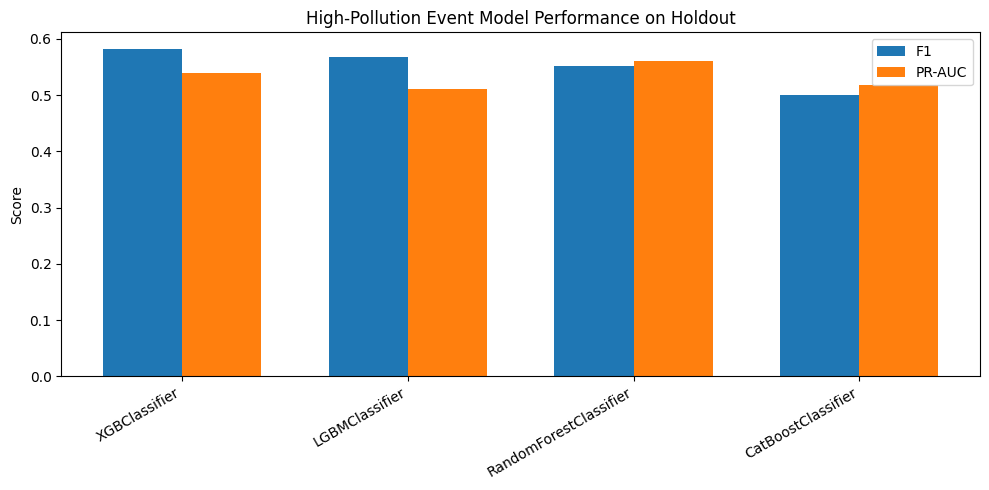

PosixPath('artifacts_astana_pm25_article/figures/figure_06_event_model_f1_pr_auc.png')

In [31]:
fig_path = FIG_DIR / "figure_06_event_model_f1_pr_auc.png"
plot_df = classification_summary.copy()
labels = plot_df["model"]
x = np.arange(len(labels))
width = 0.35
plt.figure(figsize=(10, 5))
plt.bar(x - width/2, plot_df["f1"], width=width, label="F1")
plt.bar(x + width/2, plot_df["pr_auc"], width=width, label="PR-AUC")
plt.xticks(x, labels, rotation=30, ha="right")
plt.ylabel("Score")
plt.title("High-Pollution Event Model Performance on Holdout")
plt.legend()
plt.tight_layout()
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

fig_path


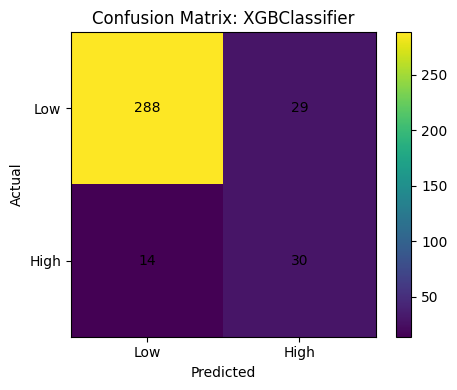

PosixPath('artifacts_astana_pm25_article/figures/figure_07_confusion_matrix_best_event_model.png')

In [32]:
fig_path = FIG_DIR / "figure_07_confusion_matrix_best_event_model.png"
cm = confusion_matrix(cls_bundle["y_holdout_cls"], (cls_holdout_score >= cls_threshold).astype(int), labels=[0, 1])
plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix: {cls_model_name}")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Low", "High"])
plt.yticks(tick_marks, ["Low", "High"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, int(cm[i, j]), ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

fig_path


## Feature importance for the regression champion


In [33]:
importance_df = None

if reg_model_name != "Rolling7_Baseline":
    result = permutation_importance(
        reg_model,
        reg_bundle["X_holdout"],
        reg_bundle["y_holdout_reg"],
        n_repeats=10,
        random_state=SEED,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )
    importance_df = pd.DataFrame({
        "feature": reg_bundle["features"],
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)

importance_df.head(20) if importance_df is not None else None


,feature,importance_mean,importance_std
0,pm25_roll_mean_7,2.797001,0.396889
1,pm25_lag_1,2.041739,0.215890
2,pm25_diff_3d,1.857064,0.240291
3,pm25_roll_min_7,1.522653,0.375135
4,pm25_roll_mean_3,1.460286,0.138921
5,pm25_diff_1d,0.965004,0.115948
6,pm25_pct_change_1d,0.527756,0.070412
7,pm25_roll_mean_30,0.160320,0.119863
8,pm10_curr,0.149320,0.121653
9,pm25_roll_mean_14,0.139587,0.085990


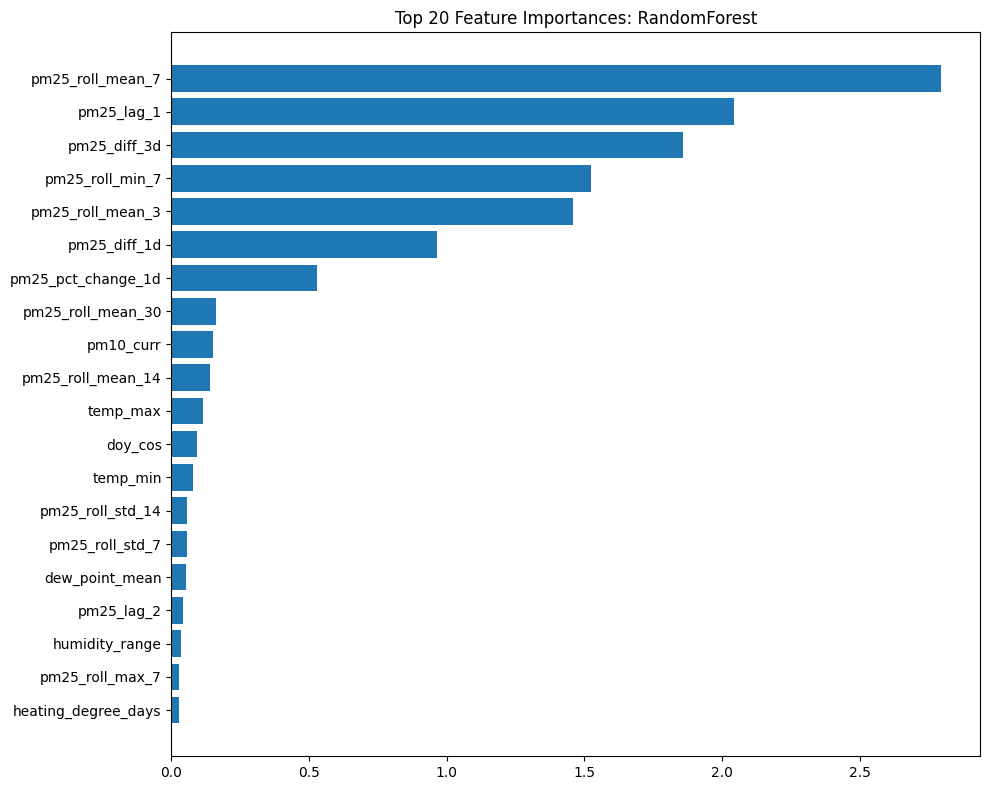

In [34]:
if importance_df is not None and len(importance_df) > 0:
    fig_path = FIG_DIR / "figure_08_top_feature_importance.png"
    top_imp = importance_df.head(20).iloc[::-1]
    plt.figure(figsize=(10, 8))
    plt.barh(top_imp["feature"], top_imp["importance_mean"])
    plt.title(f"Top 20 Feature Importances: {reg_model_name}")
    plt.tight_layout()
    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.show()
    fig_path


## Save article-ready outputs


In [35]:
cv_reg_results.to_csv(ARTIFACT_DIR / "cv_regression_fold_results.csv", index=False)
cv_reg_comparison.to_csv(ARTIFACT_DIR / "cv_regression_summary.csv", index=False)
holdout_reg_summary.to_csv(ARTIFACT_DIR / "holdout_regression_summary.csv", index=False)
pred_df.to_csv(ARTIFACT_DIR / "holdout_regression_predictions.csv", index=False)
seasonal_reg_metrics.to_csv(ARTIFACT_DIR / "seasonal_regression_metrics.csv", index=False)
monthly_reg_metrics.to_csv(ARTIFACT_DIR / "monthly_regression_metrics.csv", index=False)
seasonal_model_summary.to_csv(ARTIFACT_DIR / "seasonal_model_comparison.csv", index=False)
reg_search_results.to_csv(ARTIFACT_DIR / "regression_search_results.csv", index=False)

classification_summary.to_csv(ARTIFACT_DIR / "holdout_classification_summary.csv", index=False)
cls_search_results.to_csv(ARTIFACT_DIR / "classification_search_results.csv", index=False)

if importance_df is not None:
    importance_df.to_csv(ARTIFACT_DIR / "feature_importance.csv", index=False)

metadata = {
    "date_min": str(date_min.date()),
    "date_max": str(date_max.date()),
    "n_rows": int(len(df_raw)),
    "pm25_non_null": int(df_raw[TARGET_COL].notna().sum()),
    "pm25_missing_rate": float(df_raw[TARGET_COL].isna().mean()),
    "holdout_start_date": str(holdout_start_date.date()),
    "feature_set_sizes": {k: len(v) for k, v in feature_sets.items()},
    "search_iterations": N_ITER_SEARCH,
    "regression_models_tested": ["Rolling7_Baseline"] + list(reg_models.keys()),
    "classification_models_tested": list(cls_models.keys()),
    "regression_champion": regression_champion,
    "classification_champion": classification_champion,
    "final_regression_metrics": final_regression_metrics,
    "final_classification_metrics": cls_eval,
    "important_figures": [
        "figure_01_pm25_series.png",
        "figure_03_model_comparison_holdout_mae.png",
        "figure_04_actual_vs_predicted_holdout.png",
        "figure_06_event_model_f1_pr_auc.png",
        "figure_07_confusion_matrix_best_event_model.png",
        "figure_08_top_feature_importance.png"
    ]
}

with open(ARTIFACT_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

joblib.dump(reg_bundle["features"], ARTIFACT_DIR / "regression_feature_columns.joblib")
if reg_model_name != "Rolling7_Baseline":
    joblib.dump(reg_model, ARTIFACT_DIR / "best_regression_model.joblib")
joblib.dump(cls_bundle["features"], ARTIFACT_DIR / "classification_feature_columns.joblib")
joblib.dump(cls_model, ARTIFACT_DIR / "best_classification_model.joblib")


['artifacts_astana_pm25_article/best_classification_model.joblib']

## Final result tables


In [36]:
cv_reg_comparison


,feature_set,model,mae_mean,mae_std,rmse_mean,r2_mean,smape_mean
0,CORE_PM10,RandomForest,18.841535,10.348483,41.839409,0.184942,47.710498
1,CORE_PM10_TSP,RandomForest,18.903227,10.369484,41.836698,0.184498,47.966073
2,CORE,RandomForest,18.937215,10.638567,41.819410,0.183817,47.976581
3,CORE,Rolling7_Baseline,19.254111,8.666634,41.755403,-0.007136,50.690309
4,CORE_PM10,Rolling7_Baseline,19.254111,8.666634,41.755403,-0.007136,50.690309
5,CORE_PM10_TSP,Rolling7_Baseline,19.254111,8.666634,41.755403,-0.007136,50.690309
6,CORE_TSP,Rolling7_Baseline,19.254111,8.666634,41.755403,-0.007136,50.690309
7,CORE_TSP,RandomForest,19.583812,11.080707,41.995390,0.171339,49.275445
8,CORE_PM10,XGBoost,19.675157,10.094637,42.095417,0.134769,50.122942
9,CORE_PM10,CatBoost,19.840827,10.344806,42.926300,0.134378,51.192842


In [37]:
holdout_reg_summary


,feature_set,model,mae,rmse,r2,smape
0,CORE_PM10_TSP,RandomForest,28.340409,69.758009,0.287449,71.260615
1,CORE_PM10,RandomForest,28.465897,69.524735,0.292207,71.237496
2,CORE_TSP,RandomForest,28.738778,69.408481,0.294572,72.179544
3,CORE,RandomForest,29.067313,69.103008,0.300768,72.443653
4,CORE_TSP,CatBoost,29.424845,74.552131,0.186144,73.658923
5,CORE_PM10,CatBoost,29.648816,72.869751,0.222461,76.763773
6,CORE_PM10_TSP,CatBoost,29.871900,72.856191,0.222750,77.176216
7,CORE,CatBoost,29.914675,72.035141,0.240170,77.550484
8,CORE_TSP,LightGBM,30.943123,71.592682,0.249476,73.849873
9,CORE,LightGBM,30.962771,71.554889,0.250268,76.544300


In [38]:
classification_summary


,feature_set,model,threshold,precision,recall,f1,pr_auc,tp,fp,fn,tn
0,CORE,XGBClassifier,0.2,0.508475,0.681818,0.582524,0.538500,30,29,14,288
1,CORE,LGBMClassifier,0.2,0.621622,0.522727,0.567901,0.510237,23,14,21,303
2,CORE,RandomForestClassifier,0.3,0.475410,0.659091,0.552381,0.560441,29,32,15,285
3,CORE,CatBoostClassifier,0.2,0.555556,0.454545,0.500000,0.518421,20,16,24,301


In [39]:
seasonal_reg_metrics


,season_group,mae,rmse,r2,smape
0,cold,34.690599,75.029789,0.328064,52.409821
1,warm,21.954940,64.020699,0.085157,90.216135


In [40]:
monthly_reg_metrics.tail(12)


,month,mae,rmse,r2,smape
1,2025-04,7.828713,10.201733,-0.257801,74.914753
2,2025-05,9.950901,12.814005,-0.048648,77.065571
3,2025-06,9.790497,11.321228,-0.226026,94.064825
4,2025-07,16.953255,26.308599,0.048958,102.929729
5,2025-08,7.991843,9.730002,-0.233979,99.587464
6,2025-09,86.723592,161.165682,-0.123295,92.683380
7,2025-10,10.111235,12.391734,0.109044,58.333053
8,2025-11,24.602564,61.464097,-0.077904,75.948554
9,2025-12,87.920101,135.837546,-0.008341,62.499467
10,2026-01,56.332253,99.918236,0.293434,46.416360


## Inference examples


In [41]:
def score_next_day_pm25(raw_df: pd.DataFrame):
    x = raw_df.copy()
    x.columns = [c.strip() for c in x.columns]
    x[DATE_COL] = pd.to_datetime(x[DATE_COL], errors="coerce")
    x = x.dropna(subset=[DATE_COL]).sort_values(DATE_COL).drop_duplicates(subset=[DATE_COL], keep="last").reset_index(drop=True)
    for c in x.columns:
        if c != DATE_COL:
            x[c] = pd.to_numeric(x[c], errors="coerce")

    x = x.set_index(DATE_COL).sort_index().asfreq("D").reset_index().rename(columns={"index": DATE_COL})
    feat = build_supervised(x, horizon=FORECAST_HORIZON_DAYS)
    latest = feat.iloc[[-1]].copy()

    if reg_model_name == "Rolling7_Baseline":
        pred = float(np.clip(latest["pm25_roll_mean_7"].iloc[0], 0, None))
    else:
        model = joblib.load(ARTIFACT_DIR / "best_regression_model.joblib")
        pred = float(np.clip(model.predict(latest[reg_bundle["features"]])[0], 0, None))

    return {
        "score_date": str(latest[DATE_COL].iloc[0].date()),
        "predicted_next_day_pm25": pred
    }

score_next_day_pm25(df_raw)


{'score_date': '2026-03-24', 'predicted_next_day_pm25': 36.477297591391945}

In [42]:
def score_high_pollution_probability(raw_df: pd.DataFrame):
    x = raw_df.copy()
    x.columns = [c.strip() for c in x.columns]
    x[DATE_COL] = pd.to_datetime(x[DATE_COL], errors="coerce")
    x = x.dropna(subset=[DATE_COL]).sort_values(DATE_COL).drop_duplicates(subset=[DATE_COL], keep="last").reset_index(drop=True)
    for c in x.columns:
        if c != DATE_COL:
            x[c] = pd.to_numeric(x[c], errors="coerce")

    x = x.set_index(DATE_COL).sort_index().asfreq("D").reset_index().rename(columns={"index": DATE_COL})
    feat = build_supervised(x, horizon=FORECAST_HORIZON_DAYS)
    latest = feat.iloc[[-1]].copy()

    model = joblib.load(ARTIFACT_DIR / "best_classification_model.joblib")
    if hasattr(model, "predict_proba"):
        score = float(model.predict_proba(latest[cls_bundle["features"]])[:, 1][0])
    else:
        score = float(model.decision_function(latest[cls_bundle["features"]])[0])

    return {
        "score_date": str(latest[DATE_COL].iloc[0].date()),
        "high_pollution_probability": score,
        "decision_threshold": cls_threshold
    }

score_high_pollution_probability(df_raw)


{'score_date': '2026-03-24',
 'high_pollution_probability': 0.03790730983018875,
 'decision_threshold': 0.2}